In [4]:
### Load necessary modules -------------------------------
# interactive plotting
%matplotlib inline
%config InlineBackend.figure_format = 'svg' # ‘png’, ‘retina’, ‘jpeg’, ‘svg’, ‘pdf’

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

# Data management libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

# Data management libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Machine learning libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier

# Custom functions for this course
from utils import *

### 1. EDA

### STEP 1: IMPORT DATASET 

In [8]:
### Load file --------------------------------------------
df = pd.read_csv('TrainingSet1001_MIC.dat', sep = " ")
df.tail()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
996,-3.568369,0.496333,0.173991,0.469008,-1.184389,1.184738,2.233434,-2.874683,-0.387612,-0.889255,YES
997,1.498530,-0.264520,1.246506,-0.753459,0.611432,0.993137,0.358073,-0.505211,-0.333458,-0.900406,NO
998,-0.555710,2.062454,-1.349818,0.454693,-0.029676,-0.663155,12.418139,-1.347917,-0.174108,0.592883,NO
999,-2.758392,-0.363996,-1.077681,0.616510,-1.243385,-0.589747,-2.797988,-2.605561,-0.197662,0.926934,NO
1000,0.299375,-0.078811,-0.639723,-0.031867,-0.535257,2.862918,0.068227,-2.096067,-0.480728,4.604271,YES


### STEP 2: CHECK OUT THE MISSING VALUES 

In [11]:
### Info and type of variables & missing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1001 non-null   float64
 1   X2      1001 non-null   float64
 2   X3      1001 non-null   float64
 3   X4      1001 non-null   float64
 4   X5      1001 non-null   float64
 5   X6      1001 non-null   float64
 6   X7      1001 non-null   float64
 7   X8      1001 non-null   float64
 8   X9      1001 non-null   float64
 9   X10     1001 non-null   float64
 10  Y       1001 non-null   object 
dtypes: float64(10), object(1)
memory usage: 86.2+ KB


### STEP 3: PLOT THE DATA AND CHECK OUT FOR OUTLIERS

In [14]:
# Data types
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,-0.108160,-0.072688,-0.009107,0.082947,-0.059367,0.054219,0.557233,1.997534,-0.013371,0.915024
std,2.193279,0.971364,1.025068,0.988701,1.005401,1.002333,6.142348,3.557079,1.018022,1.921223
min,-6.914708,-3.066771,-3.810255,-3.642838,-3.503037,-3.097581,-18.671728,-3.797148,-2.796070,-0.996646
25%,-1.602385,-0.697919,-0.720853,-0.573841,-0.723352,-0.603406,-3.445660,-0.570989,-0.708445,-0.442451
50%,-0.097051,-0.068753,-0.049853,0.128076,-0.060877,0.067946,0.567798,1.212847,-0.027997,0.304359
75%,1.414675,0.604337,0.676572,0.698572,0.622266,0.749050,4.660929,3.697466,0.675977,1.623727
max,7.574398,3.364642,3.155086,3.169976,3.298336,3.374656,21.766104,20.954261,5.057228,15.582082


<Figure size 1200x1000 with 0 Axes>

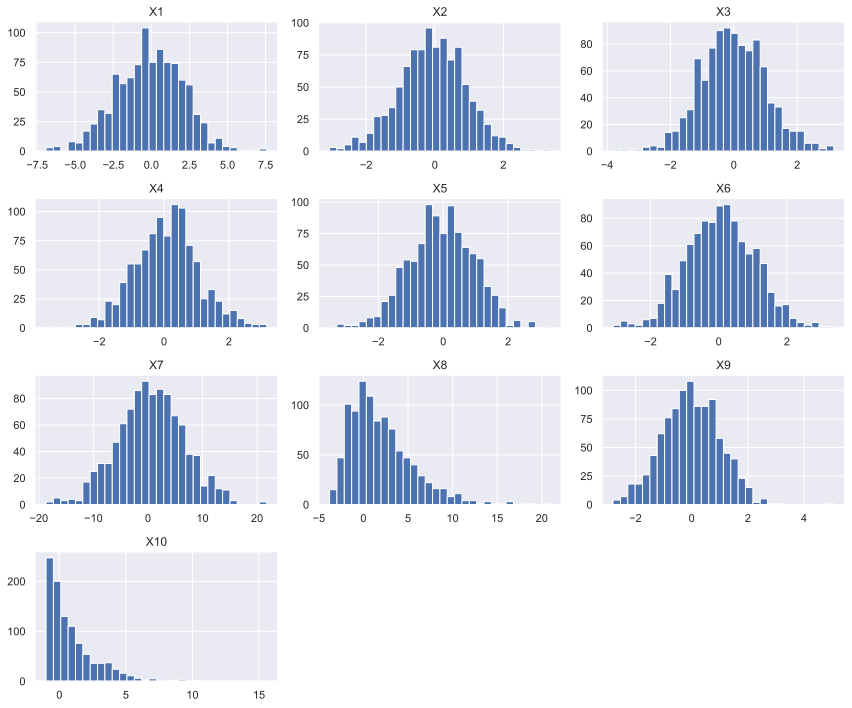

In [16]:
# Plot histograms to see how the variables are distributed

# Definir el tamaño de la figura
plt.figure(figsize=(12, 10))

# Crear un histograma para cada columna
df.hist(bins=30, figsize=(12, 10), layout=(4, 3))  # Ajusta layout según la cantidad de columnas

# Mostrar los gráficos
plt.tight_layout()
plt.show()




### STEP 4: ENCODE CATEGORICAL VARIABLES

In [19]:
# There are no categorical variables, all numerical

# convert y from float to categorical

df.Y = df.Y.astype('category')


### STEP 5: EXPLORATORY ANALYSIS (Analyze cointinuous variables)
Correlation plot of numeric variables

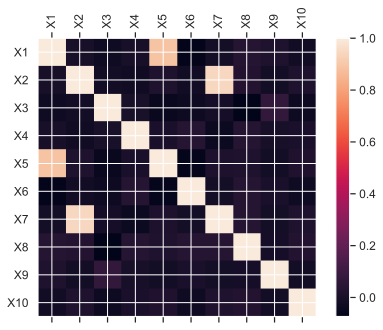

In [22]:

# Crear el gráfico de correlación
f = plt.figure(figsize=(7, 5))  # Ajustar el tamaño del gráfico
plt.matshow(df.select_dtypes(include=['int64', 'float64']).corr(), fignum=f.number)

# Ajustar las etiquetas del eje X y Y
plt.xticks(range(df.select_dtypes(include=['int64','float64']).shape[1]), 
           df.select_dtypes(include=['int64','float64']).columns, 
           fontsize=12, rotation=90)  # Rotar más las etiquetas del eje X

plt.yticks(range(df.select_dtypes(include=['int64','float64']).shape[1]), 
           df.select_dtypes(include=['int64','float64']).columns, 
           fontsize=12)

# Añadir la barra de color y ajustar el tamaño de las etiquetas
cb = plt.colorbar()
cb.ax.tick_params(labelsize=12)


# se puede observar que la unica correlación alta es la de total de trades y satisfactory trades, osea que practicamente todos los trades son satisfactorios

###### STEP 6: CHECK OUT FOR CLASS IMBALANCES

In [25]:
# Class count

variable_names = df.columns.tolist()

df['Y'].value_counts()


# Está balanceado el dataset

Y
YES    501
NO     500
Name: count, dtype: int64

In [27]:
variables_names = df.columns.tolist()
INPUTS = variables_names[0:10]
OUTPUTS = variables_names[-1]
print(INPUTS)


['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']


In [29]:
X_train = df.iloc[:, :10]
X_train.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,3.290968,0.644549,0.713098,1.948699,1.020626,0.170077,2.868211,3.647116,0.066560,-0.706168
1,3.100687,-0.782135,0.401693,0.193084,0.908419,1.165997,-0.041028,-2.850352,-2.535893,5.036424
2,-0.974291,0.881651,0.690685,-0.560430,-0.634730,-0.664597,6.635579,-0.973682,-1.267142,4.450237
3,-3.414938,-0.203968,-0.036549,-2.261589,-1.296119,-2.126754,-2.059090,5.354376,-0.112499,2.257196
4,4.798085,-0.276071,-0.964808,0.355198,1.826178,-0.640231,-2.650546,0.364302,-0.325046,3.663908


In [31]:
y_train = df.iloc[:,10]
y_train.head()

0     NO
1    YES
2    YES
3    YES
4    YES
Name: Y, dtype: category
Categories (2, object): ['NO', 'YES']

In [33]:
## Create dataset to store model predictions
dfTR_eval = X_train.copy()
dfTR_eval['Y'] = y_train # We will call Y as output variable for simplicity

dfTR_eval.head()
#dfTS_eval = X_test.copy()
#dfTS_eval['Y'] = y_test # We will call Y as output variable for simplicity

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,3.290968,0.644549,0.713098,1.948699,1.020626,0.170077,2.868211,3.647116,0.066560,-0.706168,NO
1,3.100687,-0.782135,0.401693,0.193084,0.908419,1.165997,-0.041028,-2.850352,-2.535893,5.036424,YES
2,-0.974291,0.881651,0.690685,-0.560430,-0.634730,-0.664597,6.635579,-0.973682,-1.267142,4.450237,YES
3,-3.414938,-0.203968,-0.036549,-2.261589,-1.296119,-2.126754,-2.059090,5.354376,-0.112499,2.257196,YES
4,4.798085,-0.276071,-0.964808,0.355198,1.826178,-0.640231,-2.650546,0.364302,-0.325046,3.663908,YES


### 2. LOGISTIC REGRESSION

In [36]:
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_LR = INPUTS

#ModLogReg = LogisticRegression()
LogReg_fit = Pipeline(steps=[('scaler',StandardScaler()), # Preprocess the variables when training the model 
                        ('LogReg',LogisticRegression(penalty=None))]) # Model to use in the pipeline

#Train model
LogReg_fit.fit(X_train[INPUTS_LR], y_train);

print("Logistic Regression Trained")

Logistic Regression Trained


In [38]:
# Obtain Cross-Validation score
print("CV accuracy is")
cross_val_score(LogReg_fit, X_train[INPUTS_LR], y_train, cv=10, scoring='accuracy').mean()

CV accuracy is


0.6733168316831684

In [40]:
summaryLogReg(LogReg_fit, X_train[INPUTS_LR], y_train)

Deviance Residuals:
        Min        1Q    Median        3Q       Max
0 -0.927158 -0.346148  0.000389  0.400427  0.899552

Coefficients:
           Estimate
Intercept  0.075926
X1         0.148257
X2        -0.348562
X3         0.068932
X4        -0.080099
X5        -0.213101
X6         0.647041
X7         0.228696
X8         0.067857
X9        -0.159832
X10        1.081102
           Estimate  Std. Err    t-value  Pr(>|t|) Signif
Intercept  0.075926  0.073003   1.040044  0.298319       
X1         0.148257  0.159718   0.928246  0.353280       
X2        -0.348562  0.215165  -1.619975  0.105238       
X3         0.068932  0.071715   0.961205  0.336449       
X4        -0.080099  0.071570  -1.119184  0.263062       
X5        -0.213101  0.159396  -1.336922  0.181248       
X6         0.647041  0.077608   8.337303  0.000000    ***
X7         0.228696  0.215008   1.063666  0.287480       
X8         0.067857  0.072598   0.934691  0.349948       
X9        -0.159832  0.072088  -2.217183 

In [42]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_LR_pred'] = LogReg_fit.predict(X_train[INPUTS_LR])
dfTR_eval['Y_LR_prob_neg'] = LogReg_fit.predict_proba(X_train[INPUTS_LR])[:,0]
dfTR_eval['Y_LR_prob_pos'] = LogReg_fit.predict_proba(X_train[INPUTS_LR])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_LR_pred'] = LogReg_fit.predict(X_test)
dfTS_eval['Y_LR_prob_neg'] = LogReg_fit.predict_proba(X_test[INPUTS_LR])[:,0]
dfTS_eval['Y_LR_prob_pos'] = LogReg_fit.predict_proba(X_test[INPUTS_LR])[:,1]

#visualize evaluated data
dfTR_eval.head()

NameError: name 'X_test' is not defined

In [45]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

# Reporte de clasificación para el conjunto de prueba
print("Reporte de Clasificación (Test):")
print(classification_report(y_test, dfTS_eval['Y_LR_pred']))

# Matriz de confusión para el conjunto de prueba
print("Matriz de Confusión (Test):")
print(confusion_matrix(y_test, dfTS_eval['Y_LR_pred']))

# Curva ROC para el conjunto de prueba
fpr, tpr, thresholds = roc_curve(y_test, dfTS_eval['Y_LR_prob_pos'])

plt.plot(fpr, tpr, label="Curva ROC")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC (Test)")
plt.legend(loc="best")
plt.show()

# AUC
auc_score = roc_auc_score(y_test, dfTS_eval['Y_LR_prob_pos'])
print(f"AUC (Test): {auc_score}")

# el modelo ppodría mejorar aunque no está mal 

Reporte de Clasificación (Test):


NameError: name 'y_test' is not defined

In [54]:
# CONFUSION MATRIX

'''

 def confusion_matrix(y_true:pd.core.series.Series, y_pred:pd.core.series.Series, labels, sample_weight=None, normalize:bool=True):
     """Calculate confusion matrix and classification metrics

    Args:
        y_true (pd.core.series.Series): Series containing true values of output
        y_pred (pd.core.series.Series): Series containing predicted values of output
        labels [str,str,str,...]: String vector of output categories
        sample_weight ([int, int, ...], optional): Weights assigned to output samples in training process. Defaults to None.
        normalize (bool, optional): normalize classification metrics when possible. Defaults to True.
    """

    # Calculate confusion matrix
        print('Confusion Matrix and Statistics\n\t   Prediction')
        if labels is None:
             labels = list(y_true.unique())
        cm = mtrs.confusion_matrix(y_true, y_pred, labels=labels, sample_weight=sample_weight, normalize=None)
        cm_df = pd.DataFrame(cm, columns=labels)
        cm_df = pd.DataFrame(labels, columns=['Reference']).join(cm_df)
        print(cm_df.to_string(index=False))
        # Calculate metrics depending on type of classification, multiclass or binary
        try:   
            if len(y_true.unique()) == 2: # binary
                average = 'binary'
            else: # multiclass
                average = 'macro'     
        except:
            if len(np.unique(y_true)) == 2: # binary
                average = 'binary'
            else: # multiclass
                average = 'macro'
                
        # Calculate accuracy
        acc = mtrs.accuracy_score(y_true, y_pred, normalize=normalize, sample_weight=sample_weight)
        # Calculate No Information Rate
        combos = np.array(np.meshgrid(y_pred, y_true)).reshape(2, -1)
        noi = mtrs.accuracy_score(combos[0], combos[1], normalize=normalize, sample_weight=sample_weight)
        # Calculate p-value Acc > NIR
        res = binom_test(cm.diagonal().sum(), cm.sum(), max(pd.DataFrame(cm).apply(sum,axis=1)/cm.sum()),'greater')
        # Calculate P-value mcnemar test
        MCN_pvalue = cont_tab.mcnemar(cm).pvalue
        # Calculate Kappa
        Kappa = mtrs.cohen_kappa_score(y_true, y_pred, labels=labels, sample_weight=sample_weight)
        # Obtain positive label
        pos_label = labels[0]
        # Calculate precision
        precision = mtrs.precision_score(y_true, y_pred, labels=labels, pos_label=pos_label, average=average, sample_weight=sample_weight)
        # Calculate recall 
        recall = mtrs.recall_score(y_true, y_pred, labels=labels, pos_label=pos_label, average=average, sample_weight=sample_weight)
        # Calculate F1 score
        F_score = mtrs.f1_score(y_true, y_pred, labels=labels, pos_label=pos_label, average=average, sample_weight=sample_weight)
        # Calculate balanced accuracy
        Balanced_acc = mtrs.balanced_accuracy_score(y_true, y_pred, sample_weight=sample_weight)
        if average == 'binary': # binary
            # Calculate sensitivity, specificity et al
            TP = cm[1,1]
            TN = cm[0,0]
            FP = cm[0,1]
            FN = cm[1,0]
            sens = TP / (TP + FN)
            spec = TN / (TN + FP)
            Prevalence = (TP + FN) / (TP + TN + FP + FN)
            Detection_rate = TP / (TP + TN + FP + FN)
            Detection_prevalence = (TP + FP) /  (TP + TN + FP + FN)
            
            
            # print all the measures
            out_str = '\nAccuracy: ' + str(round(acc,2)) + '\n' + \
            'No Information Rate: ' + str(round(noi,2)) + '\n' + \
            'P-Value [Acc > NIR]: ' + str(round(res,2)) + '\n' + \
            'Kappa: ' + str(round(Kappa,2)) + '\n' + \
            'Mcnemar\'s Test P-Value: ' + str(round(MCN_pvalue,2)) + '\n' + \
            'Sensitivity: ' + str(round(sens,2)) + '\n' + \
            'Specificity: ' + str(round(spec,2)) + '\n' + \
            'Precision: ' + str(round(precision,2)) + '\n' + \
            'Recall: ' + str(round(recall,2)) + '\n' + \
            'Prevalence: ' + str(round(Prevalence,2)) + '\n' + \
            'Detection Rate: ' + str(round(Detection_rate,2)) + '\n' + \
            'Detection prevalence: ' + str(round(Detection_prevalence,2)) + '\n' + \
            'Balanced accuracy: ' + str(round(Balanced_acc,2)) + '\n' + \
            'F1 Score: ' + str(round(F_score,2)) + '\n' + \
            'Positive label: ' + str(pos_label) 
        else: # multiclass
                    # print all the measures
            out_str = '\nAccuracy: ' + str(round(acc,2)) + '\n' + \
            'No Information Rate: ' + str(round(noi,2)) + '\n' + \
            'P-Value [Acc > NIR]: ' + str(round(res,2)) + '\n' + \
            'Kappa: ' + str(round(Kappa,2)) + '\n' + \
            'Mcnemar\'s Test P-Value: ' + str(round(MCN_pvalue,2)) + '\n' + \
            'Precision: ' + str(round(precision,2)) + '\n' + \
            'Recall: ' + str(round(recall,2)) + '\n' + \
            'Balanced accuracy: ' + str(round(Balanced_acc,2)) + '\n' + \
            'F1 Score: ' + str(round(F_score,2))  + '\n' + \
            'Positive label: ' + str(pos_label) 
        print(out_str)
        

'''

'\n\n def confusion_matrix(y_true:pd.core.series.Series, y_pred:pd.core.series.Series, labels, sample_weight=None, normalize:bool=True):\n     """Calculate confusion matrix and classification metrics\n\n    Args:\n        y_true (pd.core.series.Series): Series containing true values of output\n        y_pred (pd.core.series.Series): Series containing predicted values of output\n        labels [str,str,str,...]: String vector of output categories\n        sample_weight ([int, int, ...], optional): Weights assigned to output samples in training process. Defaults to None.\n        normalize (bool, optional): normalize classification metrics when possible. Defaults to True.\n    """\n\n    # Calculate confusion matrix\n        print(\'Confusion Matrix and Statistics\n\t   Prediction\')\n        if labels is None:\n             labels = list(y_true.unique())\n        cm = mtrs.confusion_matrix(y_true, y_pred, labels=labels, sample_weight=sample_weight, normalize=None)\n        cm_df = pd.Da

In [55]:
confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_LR_pred'],labels = [1,0])

array([[1484,  546],
       [ 560, 1387]], dtype=int64)

### 3. K-Nearest Neighbours


In [46]:
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier  # problema de clasificación
# from sklearn.neighbors import KNeighborsRegressor  # Si es un problema de regresión

from sklearn.metrics import accuracy_score  # Para clasificación
# from sklearn.metrics import mean_squared_error  # Para regresión

# Crear el modelo KNN para clasificación
knn_classifier = KNeighborsClassifier(n_neighbors = 10)  

# Entrenar el modelo
knn_classifier.fit(X_train, y_train)

# Hacer predicciones
y_pred = knn_classifier.predict(X_test)

# Evaluar el modelo con accuracy (precisión)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

NameError: name 'X_test' is not defined

In [57]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
'''

def knn_cross_validation(n_folds, k_values, X_train, y_train):
    Perform k-Nearest Neighbors (kNN) cross-validation to find the optimal value of k.

    This function performs k-fold cross-validation using the kNN algorithm from scikit-learn.
    It evaluates different values of k (number of neighbors) and selects the one that gives 
    the highest validation accuracy. The function then trains a final kNN model using the 
    entire dataset with the optimal value of k.

    Args:
        n_folds (int): The number of folds to use in cross-validation.
        k_values (list of int): A list of k values (number of neighbors) to evaluate.
        X_train (np.ndarray): The input features as a NumPy array.
        y_train (np.ndarray): The target variable as a NumPy array.

    Returns:
        tuple: A tuple containing:
            - k_optimal (int): The value of k with the highest validation accuracy.
            - final_knn (KNeighborsClassifier): A trained kNN model using the optimal k 
              on the entire dataset.

    Example:
        >>> X_train = np.array([[1, 2], [2, 4], [3, 6], [4, 8], [5, 10], [6, 12]])
        >>> y_train = np.array([0, 0, 0, 1, 1, 1])
        >>> k_values = [1, 3, 5]
        >>> n_folds = 3
        >>> k_optimal, final_model = knn_cross_validation(n_folds, k_values, X_train, y_train)
        
    '''


# Vamos a hacer cross validation para encontrar el número de vecinos óptimo

#---------- KNN MODEL ------------------

## Inputs of the model. Change accordingly to
INPUTS_KNN = INPUTS

## Configure model and hyparameter tuning
param = {'knn__n_neighbors': range(3, 135, 4)} #Number of neighbors
# param = {'knn__n_neighbors': [150]} # Uncomment in case only one parameter is wanted

# Scale data previous to fit
pipe = Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 

nFolds = 10
knn_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                        param_grid=param, # Defined grid to search in
                        n_jobs=-1, # Number of cores to use (parallelize)
                        scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                        cv=nFolds) # Number of Folds 

# Search in grid and train model --------------------
knn_fit.fit(X_train[INPUTS_KNN], y_train) 

print("kNN Trained")

kNN Trained


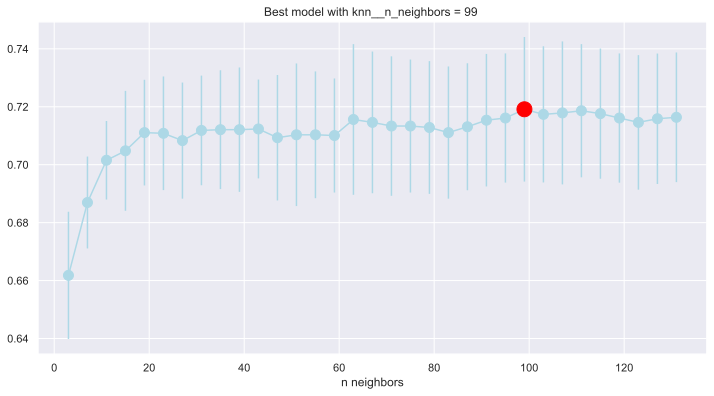

In [58]:
plotModelGridError(knn_fit)

In [59]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_knn_pred'] = knn_fit.predict(X_train[INPUTS_KNN])
dfTR_eval['Y_knn_prob_neg'] = knn_fit.predict_proba(X_train[INPUTS_KNN])[:,0]
dfTR_eval['Y_knn_prob_pos'] = knn_fit.predict_proba(X_train[INPUTS_KNN])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_knn_pred'] = knn_fit.predict(X_test[INPUTS_KNN])
dfTS_eval['Y_knn_prob_neg'] = knn_fit.predict_proba(X_test[INPUTS_KNN])[:,0]
dfTS_eval['Y_knn_prob_pos'] = knn_fit.predict_proba(X_test[INPUTS_KNN])[:,1]

#visualize evaluated data
dfTR_eval.head()

,ExternalRiskEstimate,NetFractionRevolvingBurden,AverageMInFile,MSinceOldestTradeOpen,PercentTradesWBalance,PercentInstallTrades,NumSatisfactoryTrades,NumTotalTrades,PercentTradesNeverDelq,Y,Y_LR_pred,Y_LR_prob_neg,Y_LR_prob_pos,Y_knn_pred,Y_knn_prob_neg,Y_knn_prob_pos
5112,55,65,24,58.0,89.0,53,18.0,19.0,95,1.0,1.0,0.095412,0.904588,1.0,0.070707,0.929293
4163,83,27,98,204.0,25.0,21,14.0,14.0,100,0.0,0.0,0.721947,0.278053,0.0,0.787879,0.212121
3974,63,83,111,349.0,91.0,6,34.0,35.0,97,1.0,1.0,0.388917,0.611083,1.0,0.323232,0.676768
6268,74,42,140,297.0,69.0,21,24.0,28.0,89,1.0,0.0,0.655472,0.344528,0.0,0.636364,0.363636
4690,75,61,79,279.0,60.0,19,16.0,16.0,100,0.0,1.0,0.468239,0.531761,0.0,0.585859,0.414141


In [60]:
# Vamos a ver como funciona nuestro modelo con N = 99

# Inicializamos el modelo con K=99
knn = KNeighborsClassifier(n_neighbors=99)

# Entrenamos el modelo
knn.fit(X_train, y_train)

# Hacemos predicciones
y_pred_knn = knn.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_knn))

# Matriz de confusión
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_knn))


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.67      0.73      0.70       487
         1.0       0.72      0.65      0.68       508

    accuracy                           0.69       995
   macro avg       0.69      0.69      0.69       995
weighted avg       0.69      0.69      0.69       995

Matriz de Confusión:
[[355 132]
 [176 332]]


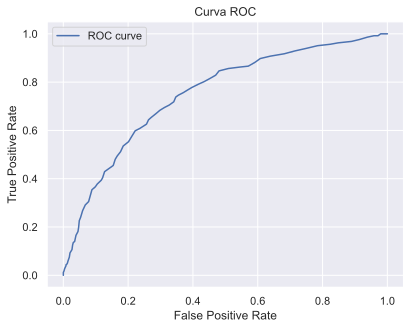

AUC: 0.7507275784572103


In [61]:
from sklearn.metrics import roc_curve, roc_auc_score


# Calcular probabilidades para la clase positiva
y_prob_knn = knn.predict_proba(X_test)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)

plt.plot(fpr, tpr, label="ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="best")
plt.show()

# AUC
auc_score = roc_auc_score(y_test, y_prob_knn)
print(f"AUC: {auc_score}")

# podria mejorarse bastante, no esta mal el modelo pero es cutre

### 4. Decision Trees 


In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

In [63]:
#-------------------------------------------------------------------------------------------------
#---------------------------- DECISION TREE MODEL ------------------------------------------------
#-------------------------------------------------------------------------------------------------
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_DT = INPUTS

# param = {'DT__min_impurity_decrease': np.arange(0,0.05,0.005)} # Minimum entropy to decrease in each split
param = {
        'DT__min_impurity_decrease': np.arange(0, 0.05, 0.005), # Minimum entropy to decrease in each split. Rango de valores y cross validation
        'DT__min_samples_split':[2, 5, 10, 20], # rango de valores y cross validation
        'DT__min_samples_leaf':[1, 2, 5, 10] # rango de valores y CV  
} 
pipe = Pipeline(steps=[('scaler', StandardScaler()), 
                       ('DT', DecisionTreeClassifier(criterion='gini',  # impuriry measure
                                                    # min_samples_split=5, # Minimum number of obs in node to keep cutting
                                                     # min_samples_leaf=5, # Minimum number of obs in a terminal node
                                                     random_state=150))]) # For replication

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
tree_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
tree_fit.fit(X_train[INPUTS_DT], y_train) # Search in grid

C:\Users\alber\anaconda3\envs\ML\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('DT',
                                        DecisionTreeClassifier(random_state=150))]),
             n_jobs=-1,
             param_grid={'DT__min_impurity_decrease': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045]),
                         'DT__min_samples_leaf': [1, 2, 5, 10],
                         'DT__min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

ValueError: Index contains duplicate entries, cannot reshape

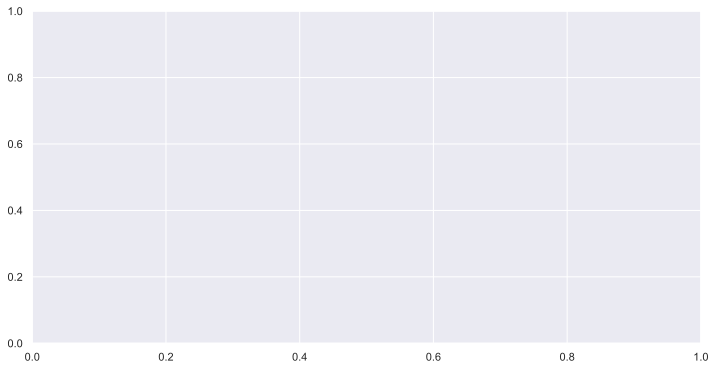

In [64]:
plotModelGridError(tree_fit)

In [ ]:
# Obtener el mejor modelo (pipeline con los mejores parámetros)
best_model = tree_fit.best_estimator_

# Mostrar el mejor modelo y sus parámetros
print("Mejor modelo encontrado por GridSearchCV:")
print(best_model)
# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros encontrados:")
print(tree_fit.best_params_)

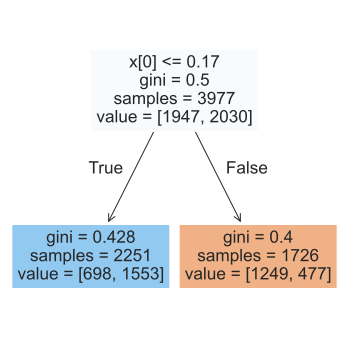

In [65]:
## Plot the decision tree model
plt.figure(figsize=(6, 6))
plot_tree(tree_fit.best_estimator_['DT'], filled=True)
plt.show()

In [66]:
#### voy a hacer cross val para sacar la impurity 



ValueError: Index contains duplicate entries, cannot reshape

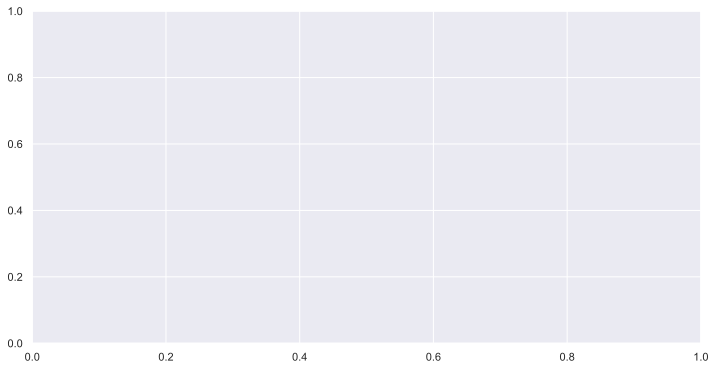

In [67]:
plotModelGridError(tree_fit)
# vemos que desde 0.01 hasta 0.045 los valores de impurity no influyen, buscaremos coger aquel que haga el modelo mas simple 

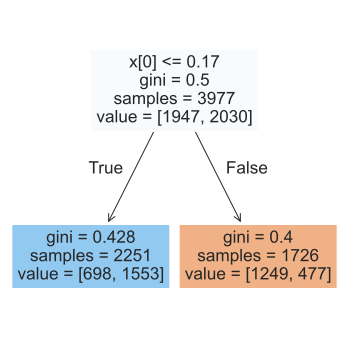

In [68]:
## Plot the decision tree model
plt.figure(figsize=(6, 6))
plot_tree(tree_fit.best_estimator_['DT'], filled=True)
plt.show()

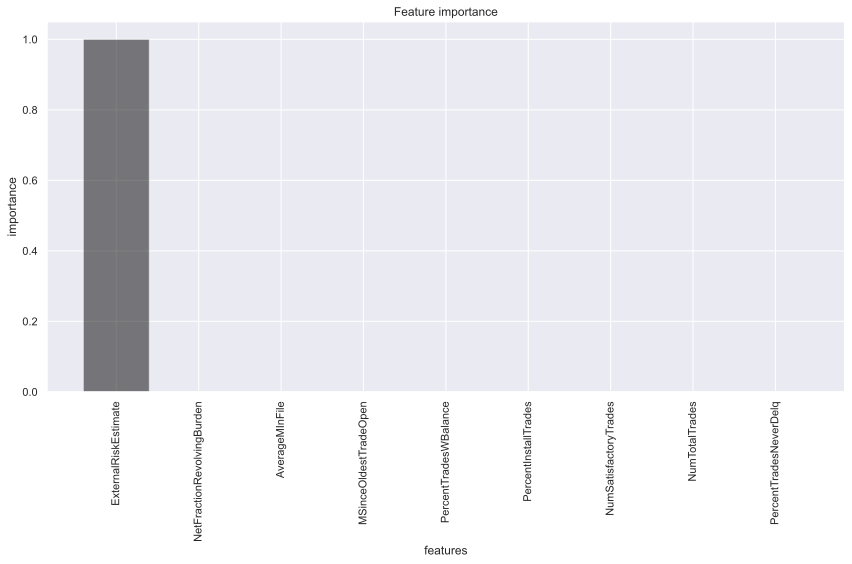

In [69]:
## Plot the variable importance of each feature

plt.figure(figsize=(12, 8)) #6 * 1.618, 6
index = np.arange(len(X_train[INPUTS_DT].columns))
bar_width = 0.35

plt.bar(index, tree_fit.best_estimator_['DT'].feature_importances_, color='black', alpha=0.5)

plt.xlabel('features')
plt.ylabel('importance')
plt.title('Feature importance')

# Rotar las etiquetas para que no se superpongan
plt.xticks(index, X_train[INPUTS_DT].columns, rotation=90)

plt.tight_layout()
plt.show()

In [70]:
print(X_train[INPUTS_DT].shape)
print(tree_fit.best_estimator_['DT'].feature_importances_)



(3977, 9)
[1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [71]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_DT_pred'] = tree_fit.predict(X_train[INPUTS_DT])
dfTR_eval['Y_DT_prob_neg'] = tree_fit.predict_proba(X_train[INPUTS_DT])[:,0]
dfTR_eval['Y_DT_prob_pos'] = tree_fit.predict_proba(X_train[INPUTS_DT])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_DT_pred'] = tree_fit.predict(X_test[INPUTS_DT])
dfTS_eval['Y_DT_prob_neg'] = tree_fit.predict_proba(X_test[INPUTS_DT])[:,0]
dfTS_eval['Y_DT_prob_pos'] = tree_fit.predict_proba(X_test[INPUTS_DT])[:,1]

#visualize evaluated data
dfTR_eval.head()

,ExternalRiskEstimate,NetFractionRevolvingBurden,AverageMInFile,MSinceOldestTradeOpen,PercentTradesWBalance,PercentInstallTrades,NumSatisfactoryTrades,NumTotalTrades,PercentTradesNeverDelq,Y,Y_LR_pred,Y_LR_prob_neg,Y_LR_prob_pos,Y_knn_pred,Y_knn_prob_neg,Y_knn_prob_pos,Y_DT_pred,Y_DT_prob_neg,Y_DT_prob_pos
5112,55,65,24,58.0,89.0,53,18.0,19.0,95,1.0,1.0,0.095412,0.904588,1.0,0.070707,0.929293,1.0,0.310084,0.689916
4163,83,27,98,204.0,25.0,21,14.0,14.0,100,0.0,0.0,0.721947,0.278053,0.0,0.787879,0.212121,0.0,0.723638,0.276362
3974,63,83,111,349.0,91.0,6,34.0,35.0,97,1.0,1.0,0.388917,0.611083,1.0,0.323232,0.676768,1.0,0.310084,0.689916
6268,74,42,140,297.0,69.0,21,24.0,28.0,89,1.0,0.0,0.655472,0.344528,0.0,0.636364,0.363636,0.0,0.723638,0.276362
4690,75,61,79,279.0,60.0,19,16.0,16.0,100,0.0,1.0,0.468239,0.531761,0.0,0.585859,0.414141,0.0,0.723638,0.276362


In [72]:
print(dfTR_eval['Y'].value_counts())
print(dfTR_eval.columns)


Y
1.0    2030
0.0    1947
Name: count, dtype: int64
Index(['ExternalRiskEstimate', 'NetFractionRevolvingBurden', 'AverageMInFile',
       'MSinceOldestTradeOpen', 'PercentTradesWBalance',
       'PercentInstallTrades', 'NumSatisfactoryTrades', 'NumTotalTrades',
       'PercentTradesNeverDelq', 'Y', 'Y_LR_pred', 'Y_LR_prob_neg',
       'Y_LR_prob_pos', 'Y_knn_pred', 'Y_knn_prob_neg', 'Y_knn_prob_pos',
       'Y_DT_pred', 'Y_DT_prob_neg', 'Y_DT_prob_pos'],
      dtype='object')


In [73]:
# TRAIN
print('TRAIN')
print(confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_DT_pred'], labels=[0,1]))


# Calcular métricas
accuracy = accuracy_score(dfTR_eval['Y'], dfTR_eval['Y_DT_pred'])
precision = precision_score(dfTR_eval['Y'], dfTR_eval['Y_DT_pred'], pos_label=1)
recall = recall_score(dfTR_eval['Y'], dfTR_eval['Y_DT_pred'], pos_label=1)
f1 = f1_score(dfTR_eval['Y'], dfTR_eval['Y_DT_pred'], pos_label=1)

# Imprimir resultados
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

TRAIN
[[1249  698]
 [ 477 1553]]
Accuracy: 0.70
Precision: 0.69
Recall: 0.77
F1 Score: 0.73


In [74]:
# TEST
print('TEST')
print(confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_DT_pred'], labels=[0,1]))

# Calcular métricas
accuracy = accuracy_score(dfTS_eval['Y'], dfTS_eval['Y_DT_pred'])
precision = precision_score(dfTS_eval['Y'], dfTS_eval['Y_DT_pred'], pos_label=1)
recall = recall_score(dfTS_eval['Y'], dfTS_eval['Y_DT_pred'], pos_label=1)
f1 = f1_score(dfTS_eval['Y'], dfTS_eval['Y_DT_pred'], pos_label=1)

# Imprimir resultados
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Informe de clasificación completo
#print("\nClassification Report:\n", classification_report(dfTS_eval['Y'], dfTS_eval['Y_DT_pred'], target_names=[0, 1]))

TEST
[[313 174]
 [122 386]]
Accuracy: 0.70
Precision: 0.69
Recall: 0.76
F1 Score: 0.72


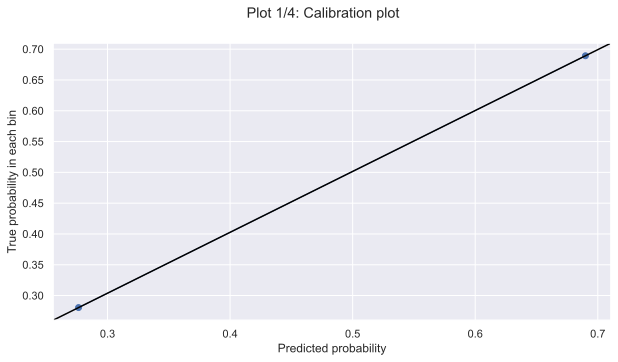

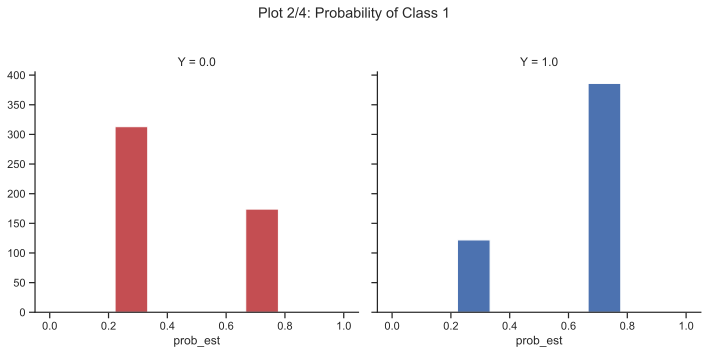

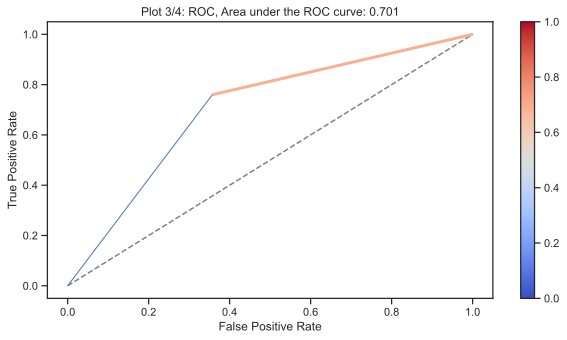

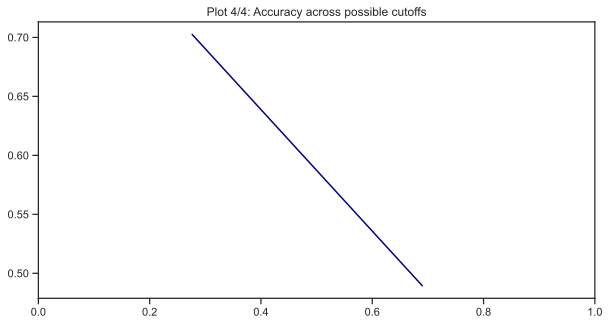

In [75]:
plotClassPerformance(dfTS_eval['Y'], tree_fit.predict_proba(X_test[INPUTS_DT]), selClass=1)

## Random Forest

In [76]:
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_RF = INPUTS

param = {'RF__n_estimators': range(10, 200, 10)} #Number of trees to grow
pipe = Pipeline(steps=[('scaler', StandardScaler()), 
                       ('RF', RandomForestClassifier(criterion='gini', # impuriry measure
                                                    max_features=len(X_train.columns),  # number of variables randomly sampled as candidates at each split.
                                                    min_samples_split=5,  # Minimum number of obs in node to keep cutting
                                                    min_samples_leaf=5, # Minimum number of obs in a terminal node
                                                    random_state=150))]) # For replication

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
rf_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
rf_fit.fit(X_train[INPUTS_RF], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('RF',
                                        RandomForestClassifier(max_features=9,
                                                               min_samples_leaf=5,
                                                               min_samples_split=5,
                                                               random_state=150))]),
             n_jobs=-1, param_grid={'RF__n_estimators': range(10, 200, 10)},
             scoring='accuracy')

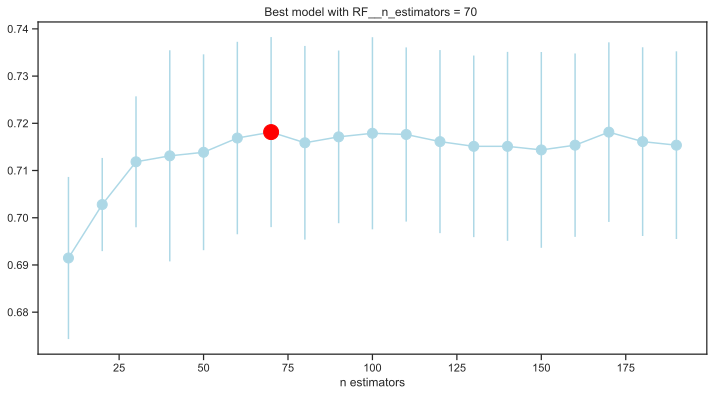

In [78]:
plotModelGridError(rf_fit)

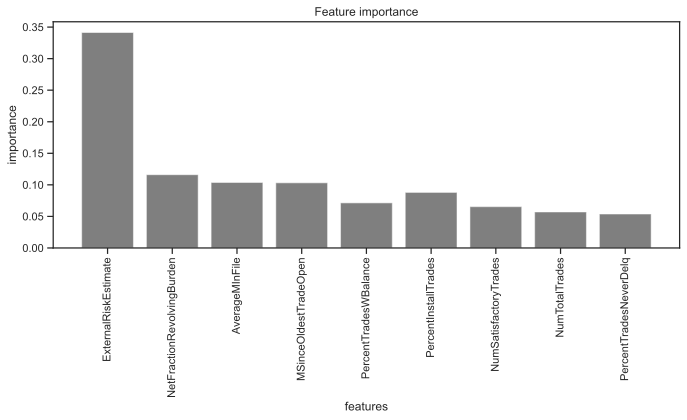

In [79]:
## Plot the variable importance of each feature
plt.figure(figsize=(6 * 1.618, 6))
index = np.arange(len(X_train[INPUTS_RF].columns))
bar_width = 0.35
plt.bar(index, rf_fit.best_estimator_['RF'].feature_importances_, color='black', alpha=0.5)
plt.xlabel('features')
plt.ylabel('importance')
plt.title('Feature importance')
plt.xticks(index, X_train.columns, rotation=90)
plt.tight_layout()
plt.show()

In [80]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_RF_pred'] = rf_fit.predict(X_train[INPUTS_RF])
dfTR_eval['Y_RF_prob_neg'] = rf_fit.predict_proba(X_train[INPUTS_RF])[:,0]
dfTR_eval['Y_RF_prob_pos'] = rf_fit.predict_proba(X_train[INPUTS_RF])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_RF_pred'] = rf_fit.predict(X_test[INPUTS_RF])
dfTS_eval['Y_RF_prob_neg'] = rf_fit.predict_proba(X_test[INPUTS_RF])[:,0]
dfTS_eval['Y_RF_prob_pos'] = rf_fit.predict_proba(X_test[INPUTS_RF])[:,1]

dfTR_eval.head()

,ExternalRiskEstimate,NetFractionRevolvingBurden,AverageMInFile,MSinceOldestTradeOpen,PercentTradesWBalance,PercentInstallTrades,NumSatisfactoryTrades,NumTotalTrades,PercentTradesNeverDelq,Y,...,Y_LR_prob_pos,Y_knn_pred,Y_knn_prob_neg,Y_knn_prob_pos,Y_DT_pred,Y_DT_prob_neg,Y_DT_prob_pos,Y_RF_pred,Y_RF_prob_neg,Y_RF_prob_pos
5112,55,65,24,58.0,89.0,53,18.0,19.0,95,1.0,...,0.904588,1.0,0.070707,0.929293,1.0,0.310084,0.689916,1.0,0.037914,0.962086
4163,83,27,98,204.0,25.0,21,14.0,14.0,100,0.0,...,0.278053,0.0,0.787879,0.212121,0.0,0.723638,0.276362,0.0,0.846186,0.153814
3974,63,83,111,349.0,91.0,6,34.0,35.0,97,1.0,...,0.611083,1.0,0.323232,0.676768,1.0,0.310084,0.689916,1.0,0.218429,0.781571
6268,74,42,140,297.0,69.0,21,24.0,28.0,89,1.0,...,0.344528,0.0,0.636364,0.363636,0.0,0.723638,0.276362,1.0,0.455320,0.544680
4690,75,61,79,279.0,60.0,19,16.0,16.0,100,0.0,...,0.531761,0.0,0.585859,0.414141,0.0,0.723638,0.276362,0.0,0.797515,0.202485


In [81]:
# TRAIN
print('TRAIN')
print(confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_RF_pred'], labels=[0, 1]))

# Calcular métricas
accuracy = accuracy_score(dfTR_eval['Y'], dfTR_eval['Y_DT_pred'])
precision = precision_score(dfTR_eval['Y'], dfTR_eval['Y_DT_pred'], pos_label=1)
recall = recall_score(dfTR_eval['Y'], dfTR_eval['Y_DT_pred'], pos_label=1)
f1 = f1_score(dfTR_eval['Y'], dfTR_eval['Y_DT_pred'], pos_label=1)

# Imprimir resultados
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

TRAIN
[[1745  202]
 [ 189 1841]]
Accuracy: 0.70
Precision: 0.69
Recall: 0.77
F1 Score: 0.73


In [82]:
# TEST
print('TEST')
print(confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_RF_pred'], labels=[0, 1]))

# Calcular métricas
accuracy = accuracy_score(dfTS_eval['Y'], dfTS_eval['Y_DT_pred'])
precision = precision_score(dfTS_eval['Y'], dfTS_eval['Y_DT_pred'], pos_label=1)
recall = recall_score(dfTS_eval['Y'], dfTS_eval['Y_DT_pred'], pos_label=1)
f1 = f1_score(dfTS_eval['Y'], dfTS_eval['Y_DT_pred'], pos_label=1)

# Imprimir resultados
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

TEST
[[338 149]
 [123 385]]
Accuracy: 0.70
Precision: 0.69
Recall: 0.76
F1 Score: 0.72


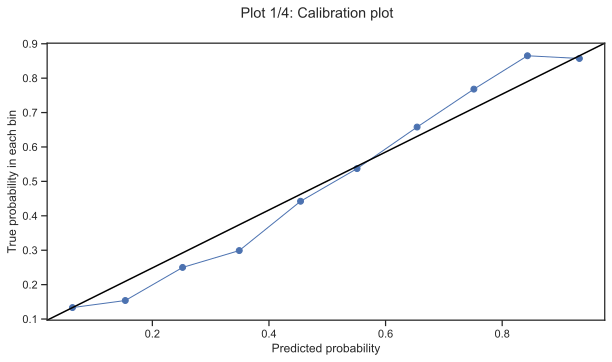

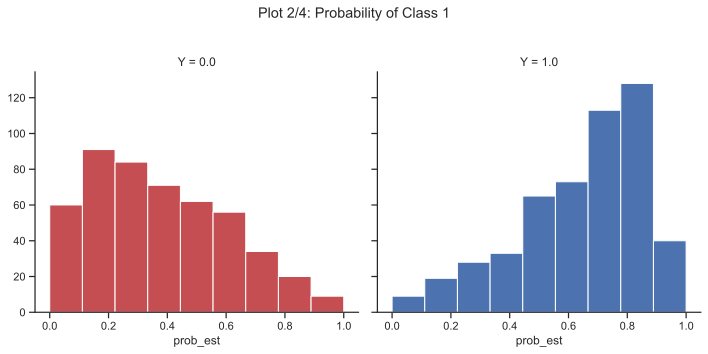

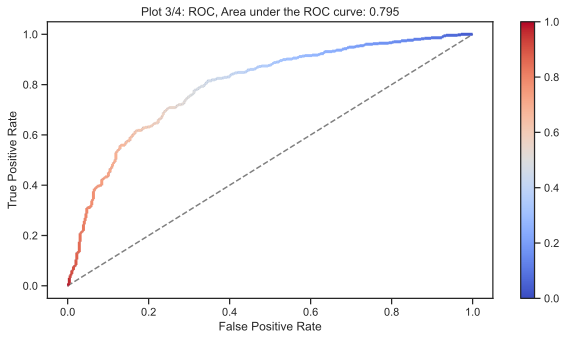

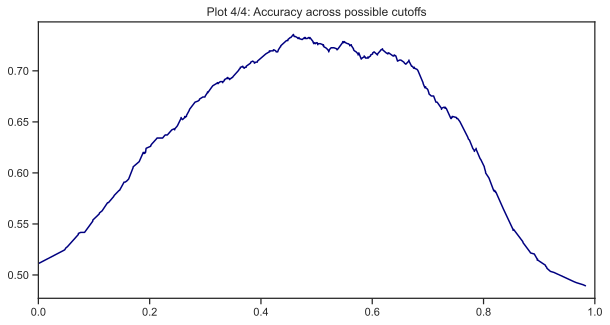

In [83]:
plotClassPerformance(dfTS_eval['Y'], rf_fit.predict_proba(X_test[INPUTS_RF]), selClass=1)

### 5. Support Vector Machines (SVM)

In [44]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV


In [46]:
#-------------------------------------------------------------------------------------------------
#------------------------------- LINEAR SVM MODEL ------------------------------------------------
#-------------------------------------------------------------------------------------------------
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_LSVC = INPUTS

param = {'SVC__C': [0.00001,0.0001,0.001,0.01,0.1,1,10,100,1000]} # Cost term
#param = {'SVC__C': [0.00001]} # Cost term
pipe = Pipeline(steps=[ ('scaler', StandardScaler()), 
                        ('SVC',  SVC(kernel='linear', # lineal kernel
                                    probability=True, # let the model predict probabilities
                                    random_state=150))]) # For replication


# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 5
Linear_SVC_gcv = GridSearchCV(estimator=pipe, # Structure of the model to use
                        param_grid=param, # Defined grid to search in
                        n_jobs=-1, # Number of cores to use (parallelize)
                        scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                        cv=nFolds) # Number of Folds 
Linear_SVC_gcv.fit(X_train[INPUTS_LSVC], y_train) # Search in grid

# We use Calibrated CV to transform predictions of the model to probabilities due to a known bug in scikit SVC
Linear_SVC_fit = CalibratedClassifierCV(
                        estimator=Linear_SVC_gcv, # Structure of the model to use
                        n_jobs=-1, # Number of cores to use (parallelize)
                        method='isotonic', # The method to use for calibration
                        cv=nFolds) # Number of Folds 
Linear_SVC_fit.fit(X_train[INPUTS_LSVC], y_train) # Search in grid


KeyboardInterrupt: 

In [ ]:
plotModelGridError(Linear_SVC_fit.estimator, xscale="log")

In [87]:
# Obtain Cross-Validation score
print("CV accuracy is")
cross_val_score(Linear_SVC_fit, X_train[INPUTS_LSVC], y_train, cv=10, scoring='accuracy').mean()

CV accuracy is


0.7138564358315508

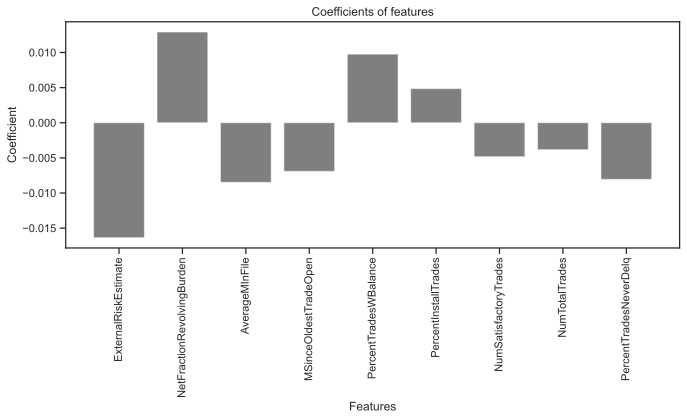

In [88]:
## Plot the variable coefficient of each feature
plt.figure(figsize=(6 * 1.618, 6))
index = np.arange(len(X_train[INPUTS_LSVC].columns))
bar_width = 0.35
plt.bar(index, Linear_SVC_fit.estimator.best_estimator_['SVC'].coef_[0,:], color='black', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Coefficient')
plt.title('Coefficients of features')
plt.xticks(index, X_train[INPUTS_LSVC].columns, rotation = 90)
plt.tight_layout()
plt.show()

In [89]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_LSVC_pred'] = Linear_SVC_fit.predict(X_train[INPUTS_LSVC])
dfTR_eval['Y_LSVC_prob_neg'] = Linear_SVC_fit.predict_proba(X_train[INPUTS_LSVC])[:,0]
dfTR_eval['Y_LSVC_prob_pos'] = Linear_SVC_fit.predict_proba(X_train[INPUTS_LSVC])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_LSVC_pred'] = Linear_SVC_fit.predict(X_test[INPUTS_LSVC])
dfTS_eval['Y_LSVC_prob_neg'] = Linear_SVC_fit.predict_proba(X_test[INPUTS_LSVC])[:,0]
dfTS_eval['Y_LSVC_prob_pos'] = Linear_SVC_fit.predict_proba(X_test[INPUTS_LSVC])[:,1]

#visualize evaluated data
dfTR_eval.head()

,ExternalRiskEstimate,NetFractionRevolvingBurden,AverageMInFile,MSinceOldestTradeOpen,PercentTradesWBalance,PercentInstallTrades,NumSatisfactoryTrades,NumTotalTrades,PercentTradesNeverDelq,Y,...,Y_knn_prob_pos,Y_DT_pred,Y_DT_prob_neg,Y_DT_prob_pos,Y_RF_pred,Y_RF_prob_neg,Y_RF_prob_pos,Y_LSVC_pred,Y_LSVC_prob_neg,Y_LSVC_prob_pos
5112,55,65,24,58.0,89.0,53,18.0,19.0,95,1.0,...,0.929293,1.0,0.310084,0.689916,1.0,0.037914,0.962086,1.0,0.097814,0.902186
4163,83,27,98,204.0,25.0,21,14.0,14.0,100,0.0,...,0.212121,0.0,0.723638,0.276362,0.0,0.846186,0.153814,0.0,0.784599,0.215401
3974,63,83,111,349.0,91.0,6,34.0,35.0,97,1.0,...,0.676768,1.0,0.310084,0.689916,1.0,0.218429,0.781571,1.0,0.415518,0.584482
6268,74,42,140,297.0,69.0,21,24.0,28.0,89,1.0,...,0.363636,0.0,0.723638,0.276362,1.0,0.455320,0.544680,0.0,0.623647,0.376353
4690,75,61,79,279.0,60.0,19,16.0,16.0,100,0.0,...,0.414141,0.0,0.723638,0.276362,0.0,0.797515,0.202485,0.0,0.572405,0.427595


In [90]:
# TRAIN
print('TRAIN')
print(confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_LSVC_pred'], labels=[0,1]))

# Calcular métricas
accuracy = accuracy_score(dfTR_eval['Y'], dfTR_eval['Y_LSVC_pred'])
precision = precision_score(dfTR_eval['Y'], dfTR_eval['Y_LSVC_pred'], pos_label=1)
recall = recall_score(dfTR_eval['Y'], dfTR_eval['Y_LSVC_pred'], pos_label=1)
f1 = f1_score(dfTR_eval['Y'], dfTR_eval['Y_LSVC_pred'], pos_label=1)

# Imprimir resultados
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

TRAIN
[[1376  571]
 [ 558 1472]]
Accuracy: 0.72
Precision: 0.72
Recall: 0.73
F1 Score: 0.72


In [91]:
# TEST
print('TEST')
print(confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_LSVC_pred'], labels=[0, 1]))

# Calcular métricas
accuracy = accuracy_score(dfTS_eval['Y'], dfTS_eval['Y_LSVC_pred'])
precision = precision_score(dfTS_eval['Y'], dfTS_eval['Y_LSVC_pred'], pos_label=1)
recall = recall_score(dfTS_eval['Y'], dfTS_eval['Y_LSVC_pred'], pos_label=1)
f1 = f1_score(dfTS_eval['Y'], dfTS_eval['Y_LSVC_pred'], pos_label=1)

# Imprimir resultados
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

TEST
[[343 144]
 [136 372]]
Accuracy: 0.72
Precision: 0.72
Recall: 0.73
F1 Score: 0.73


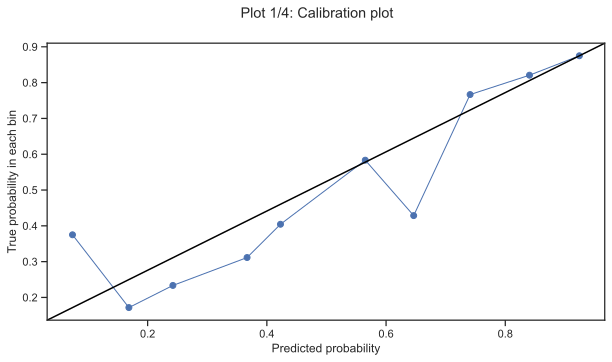

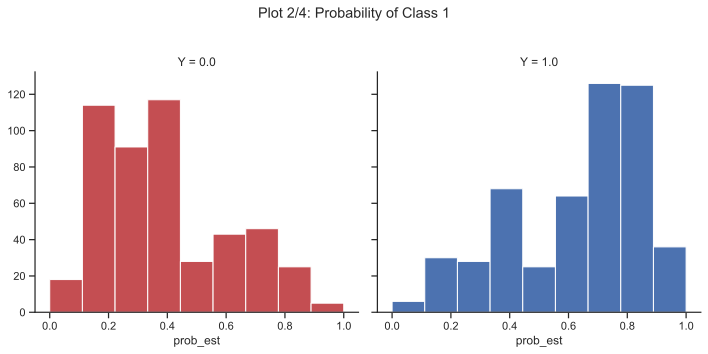

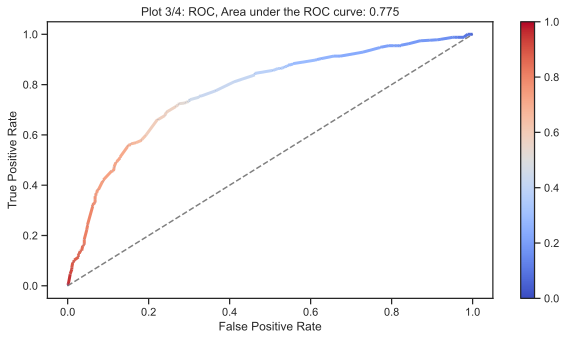

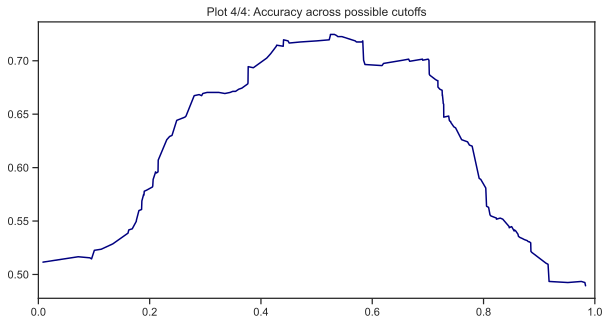

In [92]:
plotClassPerformance(dfTS_eval['Y'], Linear_SVC_fit.predict_proba(X_test[INPUTS_LSVC]), selClass=1)

In [48]:
#-------------------------------------------------------------------------------------------------
#------------------------------- RADIAL SVM MODEL ------------------------------------------------
#-------------------------------------------------------------------------------------------------
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_RSVC = INPUTS
## Train model -----------------------------------------------------------------------------------
param = {'SVC__C': [500,600,650,700,750,800,1000], # Cost term
         'SVC__gamma':[0.0075,0.01,0.02,0.03,0.04]} # Inverse width parameter in the Gaussian Radial Basis kernel 
pipe = Pipeline(steps=[('scaler', StandardScaler()), 
                       ('SVC', SVC(kernel='rbf', # lineal kernel
                                   probability=True, # let the model predict probabilities
                                   random_state=150))]) # For replication

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
SVC_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
SVC_fit.fit(X_train[INPUTS_RSVC], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('SVC',
                                        SVC(probability=True,
                                            random_state=150))]),
             n_jobs=-1,
             param_grid={'SVC__C': [500, 600, 650, 700, 750, 800, 1000],
                         'SVC__gamma': [0.0075, 0.01, 0.02, 0.03, 0.04]},
             scoring='accuracy')

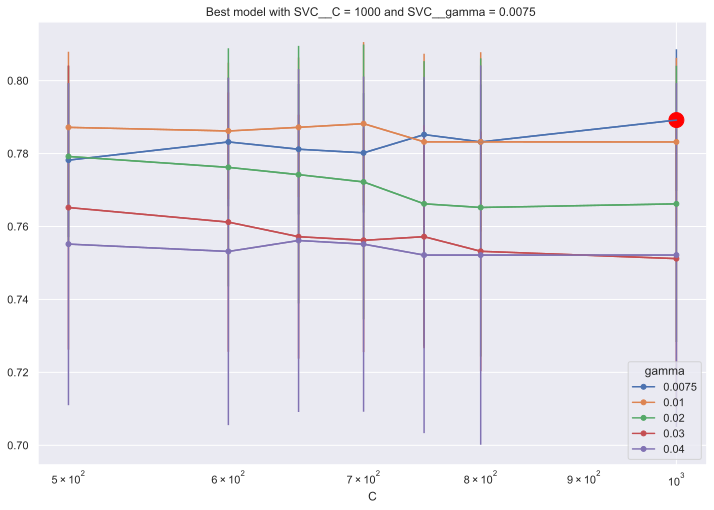

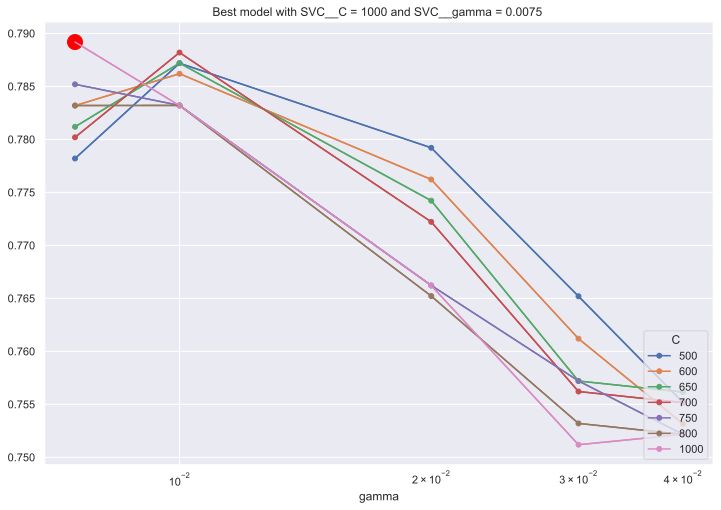

In [50]:
plotModelGridError(SVC_fit, xscale="log", xscale2='log')


In [16]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_SVC_pred'] = SVC_fit.predict(X_train[INPUTS_RSVC])
dfTR_eval['Y_SVC_prob_neg'] = SVC_fit.predict_proba(X_train[INPUTS_RSVC])[:,0]
dfTR_eval['Y_SVC_prob_pos'] = SVC_fit.predict_proba(X_train[INPUTS_RSVC])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_SVC_pred'] = SVC_fit.predict(X_test[INPUTS_RSVC])
dfTS_eval['Y_SVC_prob_neg'] = SVC_fit.predict_proba(X_test[INPUTS_RSVC])[:,0]
dfTS_eval['Y_SVC_prob_pos'] = SVC_fit.predict_proba(X_test[INPUTS_RSVC])[:,1]

dfTR_eval.head()

NameError: name 'dfTR_eval' is not defined

In [ ]:
# TRAIN
print('TRAIN')
print(confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_SVC_pred'], labels=[0,1]))

# Calcular métricas
accuracy = accuracy_score(dfTR_eval['Y'], dfTR_eval['Y_SVC_pred'])
precision = precision_score(dfTR_eval['Y'], dfTR_eval['Y_SVC_pred'], pos_label=1)
recall = recall_score(dfTR_eval['Y'], dfTR_eval['Y_SVC_pred'], pos_label=1)
f1 = f1_score(dfTR_eval['Y'], dfTR_eval['Y_SVC_pred'], pos_label=1)

# Imprimir resultados
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

In [ ]:
# TEST
print('TEST')
print(confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_SVC_pred'], labels=[0, 1]))

# Calcular métricas
accuracy = accuracy_score(dfTS_eval['Y'], dfTS_eval['Y_SVC_pred'])
precision = precision_score(dfTS_eval['Y'], dfTS_eval['Y_SVC_pred'], pos_label=1)
recall = recall_score(dfTS_eval['Y'], dfTS_eval['Y_SVC_pred'], pos_label=1)
f1 = f1_score(dfTS_eval['Y'], dfTS_eval['Y_SVC_pred'], pos_label=1)

# Imprimir resultados
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

In [ ]:
plotClassPerformance(dfTS_eval['Y'], SVC_fit.predict_proba(X_test), selClass=1)

### 6. Multi-Layer Perceptron (MLP)

In [79]:
from sklearn.neural_network import MLPClassifier
from neuralsens import partial_derivatives as ns

In [52]:
#-------------------------------------------------------------------------------------------------
#------------------------------- MLP Class MODEL -------------------------------------------------
#-------------------------------------------------------------------------------------------------
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_MLP = INPUTS

'''
param = {
    'MLP__alpha': [1e-7, 1e-5, 0.001],  # Regularización L2
    'MLP__hidden_layer_sizes': [(5,), (10,), (15,)],  # Tamaño de las capas ocultas
    'MLP__learning_rate_init': [0.001, 0.01, 0.1],  # Tasa de aprendizaje
    'MLP__max_iter': [300, 500],  # Máximo de iteraciones
    'MLP__activation': ['logistic', 'relu'],  # Función de activación
    'MLP__solver': ['lbfgs', 'adam'],  # Método de optimización
}
'''

param = {'MLP__alpha': [1e-7,1e-5,0.001,0.01], # L2 regularization term 
         'MLP__hidden_layer_sizes':[(5,),(10,),(15,),(20,),(25,)]} # Number of neurons in each hidden layer, enters as tuples
#param = {'MLP__alpha': [0], # L2 regularization term 
#         'MLP__hidden_layer_sizes':[(40,)]} # Number of neurons in each hidden layer, enters as tuples

pipe = Pipeline(steps=[('scaler', StandardScaler()), 
                       ('MLP', MLPClassifier(solver='lbfgs', # Update function
                                            activation='relu', # Logistic sigmoid activation function
                                            max_iter=450, # Maximum number of iterations
                                            tol=1e-4, # Tolerance for the optimization
                                            random_state=150,
                                            verbose = True))]) # For replication

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
MLP_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
MLP_fit.fit(X_train[INPUTS_MLP], y_train) # Search in grid

C:\Users\alber\anaconda3\envs\ML\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('MLP',
                                        MLPClassifier(max_iter=450,
                                                      random_state=150,
                                                      solver='lbfgs',
                                                      verbose=True))]),
             n_jobs=-1,
             param_grid={'MLP__alpha': [1e-07, 1e-05, 0.001, 0.01],
                         'MLP__hidden_layer_sizes': [(5,), (10,), (15,), (20,),
                                                     (25,)]},
             scoring='accuracy')

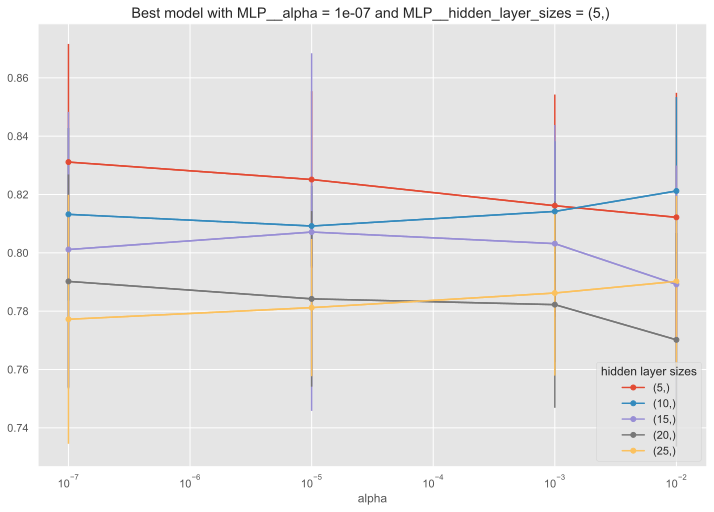

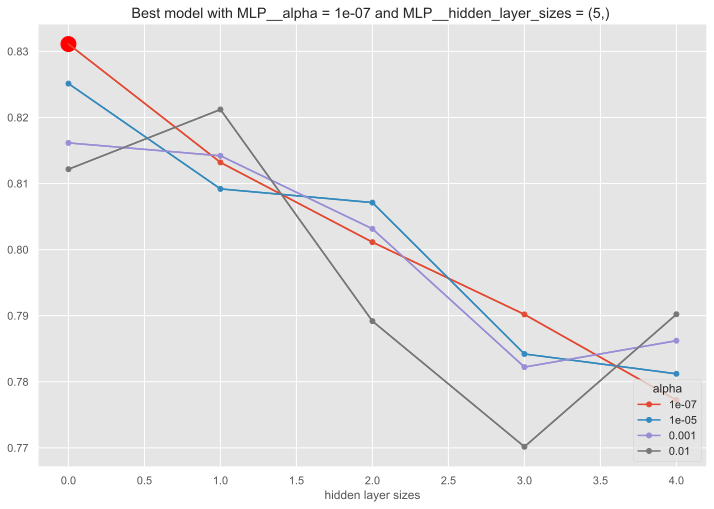

In [53]:
plotModelGridError(MLP_fit, xscale="log")

ValueError: Index contains duplicate entries, cannot reshape

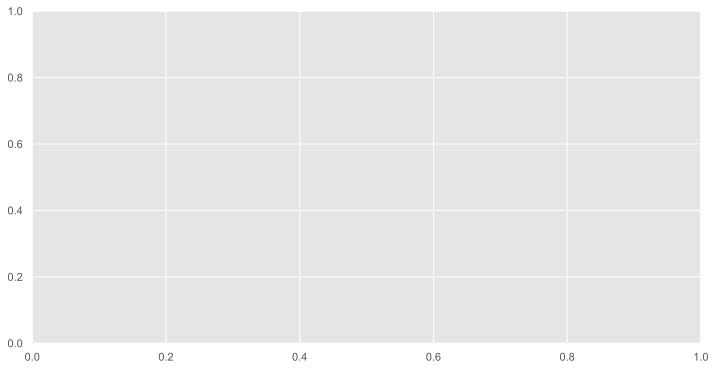

In [95]:
plotModelGridError(MLP_fit, xscale="log")

In [ ]:
#-------------------------------------------------------------------------------------------------
#------------------------------- MLP Class MODEL -------------------------------------------------
#-------------------------------------------------------------------------------------------------
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_MLP = INPUTS

'''
param = {
    'MLP__alpha': [1e-7, 1e-5, 0.001],  # Regularización L2
    'MLP__hidden_layer_sizes': [(5,), (10,), (15,)],  # Tamaño de las capas ocultas
    'MLP__learning_rate_init': [0.001, 0.01, 0.1],  # Tasa de aprendizaje
    'MLP__max_iter': [300, 500],  # Máximo de iteraciones
    'MLP__activation': ['logistic', 'relu'],  # Función de activación
    'MLP__solver': ['lbfgs', 'adam'],  # Método de optimización
}
'''

param = {#'MLP__alpha': [0.2e-7], # L2 regularization term 
         'MLP__hidden_layer_sizes':[(7,9,),(8,9,)],
         'MLP__learning_rate_init': [ 0.5e-4,0.75e-4, 1e-4,0.0002]}
#param = {'MLP__alpha': [0], # L2 regularization term 
#         'MLP__hidden_layer_sizes':[(40,)]} # Number of neurons in each hidden layer, enters as tuples

pipe = Pipeline(steps=[('scaler', StandardScaler()), 
                       ('MLP', MLPClassifier(solver='lbfgs', # Update function
                                            activation='relu', # Logistic sigmoid activation function # 1 era con relu
                                            max_iter=700, # Maximum number of iterations
                                            tol=1e-4,
                                            alpha = 0.2e-8, # Tolerance for the optimization
                                            random_state=150,
                                            verbose = True))]) # For replication

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
MLP_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
MLP_fit.fit(X_train[INPUTS_MLP], y_train) # Search in grid

In [ ]:
plotModelGridError(MLP_fit, xscale="log")

In [153]:
MLP_fit.best_params_

{'MLP__hidden_layer_sizes': (7, 9), 'MLP__learning_rate_init': 0.0002}

In [155]:
MLP_fit.best_score_

0.8661485148514851

In [101]:
dft=pd.read_csv("TestSet999_MIC.dat",sep=' ')

In [103]:
dft["y"]=MLP_fit.predict(dft)

In [105]:
dft["y"].to_csv("T19.csv",sep= " ", header= False, index= False )

In [34]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_MLP_pred'] = MLP_fit.predict(X_train[INPUTS_MLP])
dfTR_eval['Y_MLP_prob_neg'] = MLP_fit.predict_proba(X_train[INPUTS_MLP])[:,0]
dfTR_eval['Y_MLP_prob_pos'] = MLP_fit.predict_proba(X_train[INPUTS_MLP])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_MLP_pred'] = MLP_fit.predict(X_test[INPUTS_MLP])
dfTS_eval['Y_MLP_prob_neg'] = MLP_fit.predict_proba(X_test[INPUTS_MLP])[:,0]
dfTS_eval['Y_MLP_prob_pos'] = MLP_fit.predict_proba(X_test[INPUTS_MLP])[:,1]

#visualize evaluated data
dfTR_eval.head()

,ExternalRiskEstimate,NetFractionRevolvingBurden,AverageMInFile,MSinceOldestTradeOpen,PercentTradesWBalance,PercentInstallTrades,NumSatisfactoryTrades,NumTotalTrades,PercentTradesNeverDelq,Y,Y_MLP_pred,Y_MLP_prob_neg,Y_MLP_prob_pos
5112,55,65,24,58.0,89.0,53,18.0,19.0,95,1.0,1.0,0.088675,0.911325
4163,83,27,98,204.0,25.0,21,14.0,14.0,100,0.0,0.0,0.668015,0.331985
3974,63,83,111,349.0,91.0,6,34.0,35.0,97,1.0,1.0,0.270930,0.729070
6268,74,42,140,297.0,69.0,21,24.0,28.0,89,1.0,0.0,0.515030,0.484970
4690,75,61,79,279.0,60.0,19,16.0,16.0,100,0.0,0.0,0.543716,0.456284


In [ ]:
# TRAIN
print('TRAIN')
print(confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_MLP_pred'], labels=[0,1]))

# Calcular métricas
accuracy = accuracy_score(dfTR_eval['Y'], dfTR_eval['Y_MLP_pred'])
precision = precision_score(dfTR_eval['Y'], dfTR_eval['Y_MLP_pred'], pos_label=1)
recall = recall_score(dfTR_eval['Y'], dfTR_eval['Y_MLP_pred'], pos_label=1)
f1 = f1_score(dfTR_eval['Y'], dfTR_eval['Y_MLP_pred'], pos_label=1)

# Imprimir resultados
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

In [ ]:
# TEST
print('TEST')
print(confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_MLP_pred'], labels=[0,1]))

# Calcular métricas
accuracy = accuracy_score(dfTS_eval['Y'], dfTS_eval['Y_MLP_pred'])
precision = precision_score(dfTS_eval['Y'], dfTS_eval['Y_MLP_pred'], pos_label=1)
recall = recall_score(dfTS_eval['Y'], dfTS_eval['Y_MLP_pred'], pos_label=1)
f1 = f1_score(dfTS_eval['Y'], dfTS_eval['Y_MLP_pred'], pos_label=1)

# Imprimir resultados
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

In [ ]:
plotClassPerformance(dfTS_eval['Y'], MLP_fit.predict_proba(X_test[INPUTS_MLP]), selClass=1)

In [ ]:
mlp = MLP_fit.best_estimator_['MLP']
wts = mlp.coefs_
bias = mlp.intercepts_
actfunc = ['identity',MLP_fit.best_estimator_['MLP'].get_params()['activation'],mlp.out_activation_]
X = MLP_fit.best_estimator_['scaler'].transform(X_train[INPUTS_MLP])
X = pd.DataFrame(X, columns=X_train[INPUTS_MLP].columns)
y = pd.DataFrame(y_train, columns=X_train[INPUTS_MLP].columns)
sens_end_layer = 'last'
sens_end_input = False
sens_origin_layer = 0
sens_origin_input = True

In [ ]:
sensmlp = ns.jacobian_mlp(wts, bias, actfunc, X[INPUTS_MLP], y, use_torch=False)

In [ ]:
sensmlp.summary()

In [ ]:
sensmlp.info()

In [33]:
sensmlp.plot()

NameError: name 'sensmlp' is not defined